Nome: Maria Eduarda Rezende Rodrigues
RA: 165873

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


/Users/maria/Desktop/Cálculo Numérico/Colab/.venv/lib/python3.9/site-packages/matplotlib/scale.py:255: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


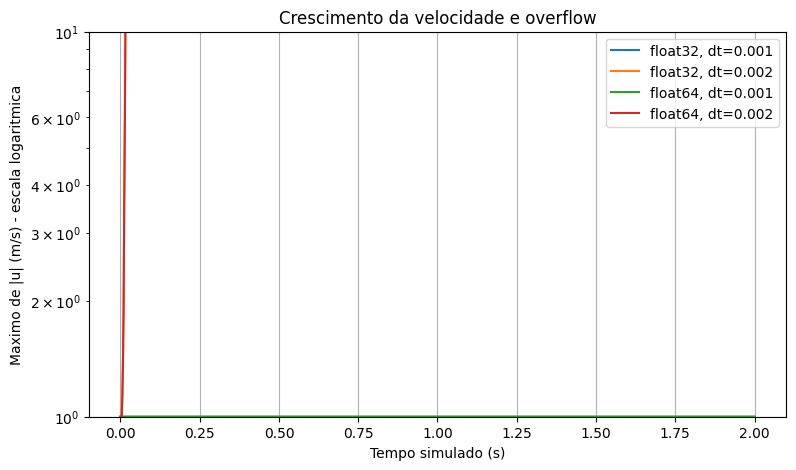

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

In [2]:
# 1. Verificação da estabilidade
# Caso A:
delta_t = 0.001
v = 10**(-4)

delta_y = 0.01 / (2000 - 1)
delta_t_max = delta_y / (2 * v)
r = (v*delta_t) / (delta_y**2)
print(f"dy = {delta_y}, dt_max = {delta_t_max}, r = {r}")

# Caso B:
delta_t = 0.002

delta_y = 0.01 / (2000 - 1)
delta_t_max = delta_y / (2 * v)
r = (v*delta_t) / (delta_y**2)
print(f"dy = {delta_y}, dt_max = {delta_t_max}, r = {r}")

dy = 5.002501250625313e-06, dt_max = 0.02501250625312656, r = 3996.001
dy = 5.002501250625313e-06, dt_max = 0.02501250625312656, r = 7992.002


In [ ]:
# 2. Detecção de overflow
import pandas as pd

data = {
    "Tipo numérico": [],
    "Passo de tempo": [],
    "r": [],
    "Ocorrência de overflow": [],
    "Iteração da falha": []
}

df = pd.DataFrame(data)

df = pd.concat(simular(tipo=np.float32))
simular(tipo=np.float64)



In [ ]:
# 3. Interpretação física

In [ ]:
# 4. Capacidade de representação

In [ ]:
# 5. Refinamento da malha

In [ ]:
# 6. Verificação do perfil de velocidade

7. Conclusão